# Week 11 Day 51: The Big Data Problem & Distributed Systems

## Big Data Foundation & Spark Architecture

This notebook introduces the problem that Big Data systems solve.

We will not start Spark immediately. First, we need to understand why tools like Excel, Pandas, and traditional single-server databases struggle when data becomes very large.

## Today's Topics

- Limitations of traditional systems
- The 5 V's of Big Data
- Vertical scaling vs horizontal scaling
- Distributed computing basics
- Challenges of distributed systems
- Data locality
- Parallel processing vs distributed processing
- Interview questions


# 1. Class Scenario: E-Commerce Clickstream Pipeline

Imagine you are a Data Engineer at a large e-commerce company.

Every user action creates an event:

```text
page_view
product_click
add_to_cart
purchase
payment_failed
search
logout
```

At small scale, this is easy.

At large scale, the company may generate:

```text
10 million events per hour
200 GB of logs per day
Several TBs of historical data
Data from web, mobile app, payment system, and warehouse system
```

Now the question is:

```text
Can Excel, Pandas, or one MySQL server handle this comfortably?
```

Usually, no.


# 2. Why Traditional Systems Struggle

Traditional tools are extremely useful, but they have limits.

## Excel

Excel is good for:

```text
small reports
manual analysis
business summaries
simple calculations
```

But it struggles with Big Data because:

```text
limited rows
limited memory
manual workflow
not designed for distributed processing
not suitable for automated production pipelines
```

## Pandas

Pandas is excellent for learning and medium-sized data.

But Pandas usually runs on one machine. If the data does not fit in memory, the notebook or process may crash.

## Traditional SQL Databases

MySQL and similar databases are powerful, but a single database server can become a bottleneck when:

```text
data size becomes too large
many users query at the same time
large joins and aggregations scan huge tables
storage and CPU are limited to one server
backup and recovery become slower
```


# 3. Demonstration: Memory Growth with Pandas

This small demo shows why data size matters.

We will create DataFrames with increasing row counts and check memory usage.

This is not Big Data, but it helps students understand the direction of the problem.


In [ ]:
import pandas as pd
import numpy as np

def create_events(n_rows):
    return pd.DataFrame({
        "event_id": np.arange(n_rows),
        "user_id": np.random.randint(1000, 9999, size=n_rows),
        "event_type": np.random.choice(["view", "click", "cart", "purchase"], size=n_rows),
        "amount": np.random.uniform(10, 5000, size=n_rows).round(2)
    })

sizes = [1_000, 10_000, 100_000, 500_000]

memory_report = []

for size in sizes:
    df = create_events(size)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    memory_report.append({
        "rows": size,
        "memory_mb": round(memory_mb, 2)
    })

pd.DataFrame(memory_report)


,rows,memory_mb
0,1000,0.07
1,10000,0.75
2,100000,7.46
3,500000,37.31


#Pandas operations getting slower with Scale

In [ ]:
import pandas as pd
import numpy as np
import time

def create_events(n_rows):
    return pd.DataFrame({
        "event_id": np.arange(n_rows),
        "user_id": np.random.randint(1000, 9999, size=n_rows),
        "event_type": np.random.choice(["view", "click", "cart", "purchase"], size=n_rows),
        "city": np.random.choice(["Delhi", "Mumbai", "Bangalore", "Pune", "Chennai"], size=n_rows),
        "amount": np.random.uniform(10, 5000, size=n_rows).round(2)
    })

sizes = [10_000, 100_000, 500_000, 1_000_000, 2_000_000]

report = []

for size in sizes:
    start = time.time()
    df = create_events(size)
    creation_time = time.time() - start

    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

    report.append({
        "rows": size,
        "memory_mb": round(memory_mb, 2),
        "creation_time_seconds": round(creation_time, 2)
    })

pd.DataFrame(report)

,rows,memory_mb,creation_time_seconds
0,10000,1.27,0.01
1,100000,12.73,0.02
2,500000,63.63,0.12
3,1000000,127.27,0.24
4,2000000,254.54,0.49


## Use groupby, because it is common in Data Engineering.

In [ ]:
sizes = [10_000, 100_000, 500_000, 1_000_000, 2_000_000]

speed_report = []

for size in sizes:
    df = create_events(size)

    start = time.time()
    result = df.groupby(["city", "event_type"])["amount"].sum().reset_index()
    groupby_time = time.time() - start

    speed_report.append({
        "rows": size,
        "groupby_time_seconds": round(groupby_time, 3),
        "output_rows": len(result)
    })

pd.DataFrame(speed_report)

,rows,groupby_time_seconds,output_rows
0,10000,0.004,20
1,100000,0.012,20
2,500000,0.054,20
3,1000000,0.119,20
4,2000000,0.219,20


# Joins are expensive and common in pipelines.

In [ ]:
events = create_events(2_000_000)

users = pd.DataFrame({
    "user_id": np.arange(1000, 9999),
    "segment": np.random.choice(["Premium", "Standard", "New"], size=8999)
})

start = time.time()

joined = events.merge(users, on="user_id", how="left")

join_time = time.time() - start

print(f"Join completed in {join_time:.2f} seconds")
print(f"Joined shape: {joined.shape}")
print(f"Memory usage: {joined.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")

Join completed in 0.15 seconds
Joined shape: (2000000, 6)
Memory usage: 359.48 MB


# Create a large CSV first:

In [ ]:
large_df = create_events(2_000_000)
large_df.to_csv("large_events.csv", index=False)

print("Large CSV created")

Large CSV created


# Now read the whole file:

In [ ]:
start = time.time()

df_full = pd.read_csv("large_events.csv")
full_result = df_full.groupby("event_type")["amount"].sum()

full_time = time.time() - start

print(f"Full read + groupby time: {full_time:.2f} seconds")
full_result

Full read + groupby time: 0.64 seconds


,amount
event_type,
cart,1.254284e+09
click,1.252036e+09
purchase,1.249506e+09
view,1.255600e+09


# Now process in chunks:

In [ ]:
start = time.time()

partial_results = []

for chunk in pd.read_csv("large_events.csv", chunksize=200_000):
    partial = chunk.groupby("event_type")["amount"].sum()
    partial_results.append(partial)

chunk_result = pd.concat(partial_results, axis=1).sum(axis=1)

chunk_time = time.time() - start

print(f"Chunk processing time: {chunk_time:.2f} seconds")
chunk_result

Chunk processing time: 0.64 seconds


,0
event_type,
cart,1.254284e+09
click,1.252036e+09
purchase,1.249506e+09
view,1.255600e+09


In [ ]:
sample_df = create_events(100_000)
sample_memory_mb = sample_df.memory_usage(deep=True).sum() / (1024 * 1024)

estimated_rows = 1_000_000_000
estimated_memory_gb = (sample_memory_mb / 100_000) * estimated_rows / 1024

print(f"Memory for 100,000 rows: {sample_memory_mb:.2f} MB")
print(f"Estimated memory for 1 billion rows: {estimated_memory_gb:.2f} GB")

Memory for 100,000 rows: 12.73 MB
Estimated memory for 1 billion rows: 124.29 GB


Chunking helps memory usage.

But it does not magically make one machine a Big Data system.

It still runs on one machine.

For TB scale, we need distributed processing.

# Show how object/string columns hurt memory

In [ ]:
df = create_events(1_000_000)

df.memory_usage(deep=True).sort_values(ascending=False)

,0
city,55201079
event_type,54249732
user_id,8000000
event_id,8000000
amount,8000000
Index,132


In [ ]:
optimized_df = df.copy()

optimized_df["event_type"] = optimized_df["event_type"].astype("category")
optimized_df["city"] = optimized_df["city"].astype("category")

before_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
after_mb = optimized_df.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Before optimization: {before_mb:.2f} MB")
print(f"After optimization: {after_mb:.2f} MB")
print(f"Memory saved: {before_mb - after_mb:.2f} MB")

Before optimization: 127.27 MB
After optimization: 24.80 MB
Memory saved: 102.47 MB


Pandas optimization helps, but it is still single-machine processing.
Optimization delays the problem. It does not eliminate the Big Data problem.

## Key Observation

As rows increase, memory usage increases.

In real systems, we may have:

```text
billions of rows
hundreds of columns
nested JSON
compressed and uncompressed files
many joins and aggregations
```

A single machine eventually becomes a bottleneck.


# 4. The 5 V's of Big Data

Big Data is commonly described using five characteristics.

## 1. Volume

Volume means the amount of data.

Examples:

```text
terabytes of logs
petabytes of images
billions of transactions
```

## 2. Velocity

Velocity means the speed at which data arrives.

Examples:

```text
clickstream events every second
IoT sensor data
stock market ticks
payment events
```

## 3. Variety

Variety means different formats and sources.

Examples:

```text
CSV
JSON
Parquet
images
logs
API responses
database tables
streaming events
```

## 4. Veracity

Veracity means data quality and trustworthiness.

Examples:

```text
missing values
duplicate records
wrong timestamps
corrupt files
invalid schema
late-arriving events
```

## 5. Value

Value means turning data into useful business outcomes.

Examples:

```text
fraud detection
customer recommendations
inventory planning
revenue analytics
real-time alerts
```


# 5. Class Activity: Identify the 5 V's

Read the scenario:

```text
A food delivery app receives 5 million location pings per minute from delivery riders.
The data arrives as JSON from mobile devices.
Some pings are missing GPS coordinates.
The business wants to predict delayed deliveries.
```

Identify:

```text
Volume:
Velocity:
Variety:
Veracity:
Value:
```


In [ ]:
# Write your answers as comments

# Volume:
# Velocity:
# Variety:
# Veracity:
# Value:


# 6. Scaling Systems

When one machine is not enough, we have two broad options:

```text
Vertical Scaling
Horizontal Scaling
```


## Vertical Scaling

Vertical scaling means making one machine bigger.

Example:

```text
Add more RAM
Add more CPU
Use faster disk
Use bigger server
```

Visual:

```text
One small server
      ↓
One bigger server
      ↓
One very expensive server
```

## Problem

There is always a limit.

At some point:

```text
hardware becomes too expensive
machine still has failure risk
disk I/O becomes bottleneck
network I/O becomes bottleneck
CPU may not be enough
one machine cannot store everything
```


## Horizontal Scaling

Horizontal scaling means adding more machines.

Example:

```text
Instead of one 1 TB RAM machine,
use many cheaper machines together.
```

Visual:

```text
Server 1
Server 2
Server 3
Server 4
Server 5
```

This is the foundation of distributed computing.


# 7. Simple Simulation: Splitting Work Across Machines

Suppose we have 1 million events.

Instead of one machine processing all events, we split data into partitions.


In [ ]:
total_events = 1_000_000
number_of_workers = 4

events_per_worker = total_events // number_of_workers

for worker_id in range(1, number_of_workers + 1):
    print(f"Worker {worker_id} processes approximately {events_per_worker:,} events")


Worker 1 processes approximately 250,000 events
Worker 2 processes approximately 250,000 events
Worker 3 processes approximately 250,000 events
Worker 4 processes approximately 250,000 events


## Key Idea

Distributed systems split work into smaller chunks.

Each worker processes part of the data.

Then results are combined.


# 8. Parallel Processing vs Distributed Processing

These two terms are related, but not exactly the same.

## Parallel Processing

Parallel processing means doing multiple tasks at the same time.

This can happen on one machine.

Example:

```text
One laptop with 8 CPU cores processes 8 chunks in parallel.
```

## Distributed Processing

Distributed processing means work is spread across multiple machines connected by a network.

Example:

```text
A Spark cluster with 10 machines processes a large dataset.
```

## Simple Difference

```text
Parallel = multiple tasks at the same time
Distributed = multiple machines working together
```

A distributed system often also uses parallel processing.


# 9. Demonstration: Parallel Thinking with Local Chunks

This example does not create a real distributed system.

It shows the basic idea of splitting a dataset, processing chunks, and combining results.


In [ ]:
events = create_events(100_000)

chunks = np.array_split(events, 4)

partial_results = []

for i, chunk in enumerate(chunks, start=1):
    result = chunk.groupby("event_type")["amount"].sum().reset_index()
    result["worker"] = i
    partial_results.append(result)

partial_results_df = pd.concat(partial_results)

partial_results_df


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,event_type,amount,worker
0,cart,15684007.94,1
1,click,15869260.81,1
2,purchase,15503907.26,1
3,view,15668418.17,1
0,cart,15957107.74,2
1,click,15807723.92,2
2,purchase,15452177.01,2
3,view,15463134.72,2
0,cart,15959965.65,3
1,click,15937825.28,3


Now combine the partial results.


In [ ]:
final_result = (
    partial_results_df
    .groupby("event_type")["amount"]
    .sum()
    .reset_index()
    .sort_values("amount", ascending=False)
)

final_result


,event_type,amount
1,click,63174742.69
0,cart,63142671.31
2,purchase,62390656.18
3,view,62259010.28


## Spark Connection

This is similar to the idea behind distributed frameworks like Spark:

```text
Split data into partitions
Process partitions in parallel
Shuffle or combine results when required
Return final output
```

Spark does this across many machines.


# 10. Challenges of Distributed Systems

Distributed systems are powerful, but they introduce new problems.

## 1. Network Latency

Machines communicate over a network.

Network communication is slower than local memory access.

Example:

```text
Reading data from local RAM is fast.
Sending data across network is slower.
```

## 2. Data Consistency

If data is copied or distributed across machines, systems need to decide:

```text
Which copy is the latest?
What happens if two machines update at the same time?
How do we avoid duplicate or incorrect results?
```

## 3. Partial Failures

In a single-machine system:

```text
Either the machine works or it crashes.
```

In a distributed system:

```text
Worker 1 may work.
Worker 2 may fail.
Worker 3 may be slow.
Network may break.
Disk may be unavailable.
```

The system must handle partial failure.


# 11. Data Locality

Data locality is one of the most important ideas in Big Data.

## Core Principle

```text
Move the code to the data, not the data to the code.
```

Why?

Because large data is expensive and slow to move across a network.

It is better to send a small computation task to the machine where the data already exists.


## Example

Suppose a 1 TB file is stored on Machine A.

Bad approach:

```text
Move 1 TB file from Machine A to Machine B
Then process it
```

Better approach:

```text
Send the processing code to Machine A
Process data where it is stored
Return only the result
```

If the final result is only 10 MB, this saves a huge amount of network movement.


# 12. Data Locality Simulation

This is a conceptual simulation.

We compare moving full data vs moving only summary results.


In [ ]:
raw_data_size_gb = 1000
summary_result_size_gb = 0.01

network_saving = raw_data_size_gb / summary_result_size_gb

print(f"Raw data size: {raw_data_size_gb} GB")
print(f"Summary result size: {summary_result_size_gb} GB")
print(f"Moving only results can reduce network movement by {network_saving:,.0f}x")


Raw data size: 1000 GB
Summary result size: 0.01 GB
Moving only results can reduce network movement by 100,000x


## Key Takeaway

Big Data systems try to reduce unnecessary data movement.

This is why partitioning, locality, and distributed storage matter.


# 13. Data Locality in a Data Engineering Pipeline

Example pipeline:

```text
Raw clickstream logs are stored across multiple machines.

Machine 1 has logs for users 1-1000.
Machine 2 has logs for users 1001-2000.
Machine 3 has logs for users 2001-3000.
```

Instead of moving all logs to one machine, we run the same aggregation near each partition:

```text
count events
calculate revenue
filter invalid rows
extract fields
```

Then only partial summaries are moved and combined.


# 14. Why Not Just Use a Huge RAM Server?

This is a common interview question.

A very large server may help temporarily, but it is not the full solution.

Bottlenecks include:

```text
cost
hardware limits
single point of failure
disk read/write speed
network transfer speed
CPU limits
backup and recovery time
concurrent users
scaling beyond one machine
```

Big Data systems solve this by distributing storage and compute.


# 15. Big Data Processing Pattern

A common distributed processing pattern:

```text
1. Split data into partitions
2. Send computation to partitions
3. Process partitions in parallel
4. Shuffle data if needed
5. Combine partial results
6. Write final output
```

Spark follows this kind of model.


# 16. Mini Case Study: Daily Revenue from Clickstream Events

## Problem

The company has 2 TB of daily events.

Need to calculate:

```text
revenue by city
purchase count by product
failed payment count
top customers
```

## Traditional Single-Machine Approach

```text
Load all data into one machine
Run groupby
Hope memory is enough
```

## Distributed Approach

```text
Store data in partitions
Process each partition near where it is stored
Combine partial results
Write output to analytics table
```


# 17. Class Discussion

Answer these questions:

1. What would happen if one worker machine fails?
2. What if one partition is much larger than others?
3. What if data needs to be joined across machines?
4. What if network is slow?
5. What if duplicate events arrive?


In [ ]:
# Write your notes here

discussion_notes = {
    "worker_failure": "",
    "large_partition": "",
    "join_across_machines": "",
    "slow_network": "",
    "duplicate_events": ""
}

discussion_notes


{'worker_failure': '',
 'large_partition': '',
 'join_across_machines': '',
 'slow_network': '',
 'duplicate_events': ''}

# 18. Vocabulary Recap

| Term | Meaning |
|---|---|
| Big Data | Data too large, fast, or complex for traditional systems |
| Volume | Amount of data |
| Velocity | Speed of data arrival |
| Variety | Different data formats and sources |
| Veracity | Data quality and trust |
| Value | Business benefit from data |
| Vertical Scaling | Making one machine bigger |
| Horizontal Scaling | Adding more machines |
| Distributed Computing | Multiple machines working together |
| Data Locality | Process data near where it is stored |
| Partial Failure | Some parts fail while others continue |
| Partition | A chunk of a larger dataset |


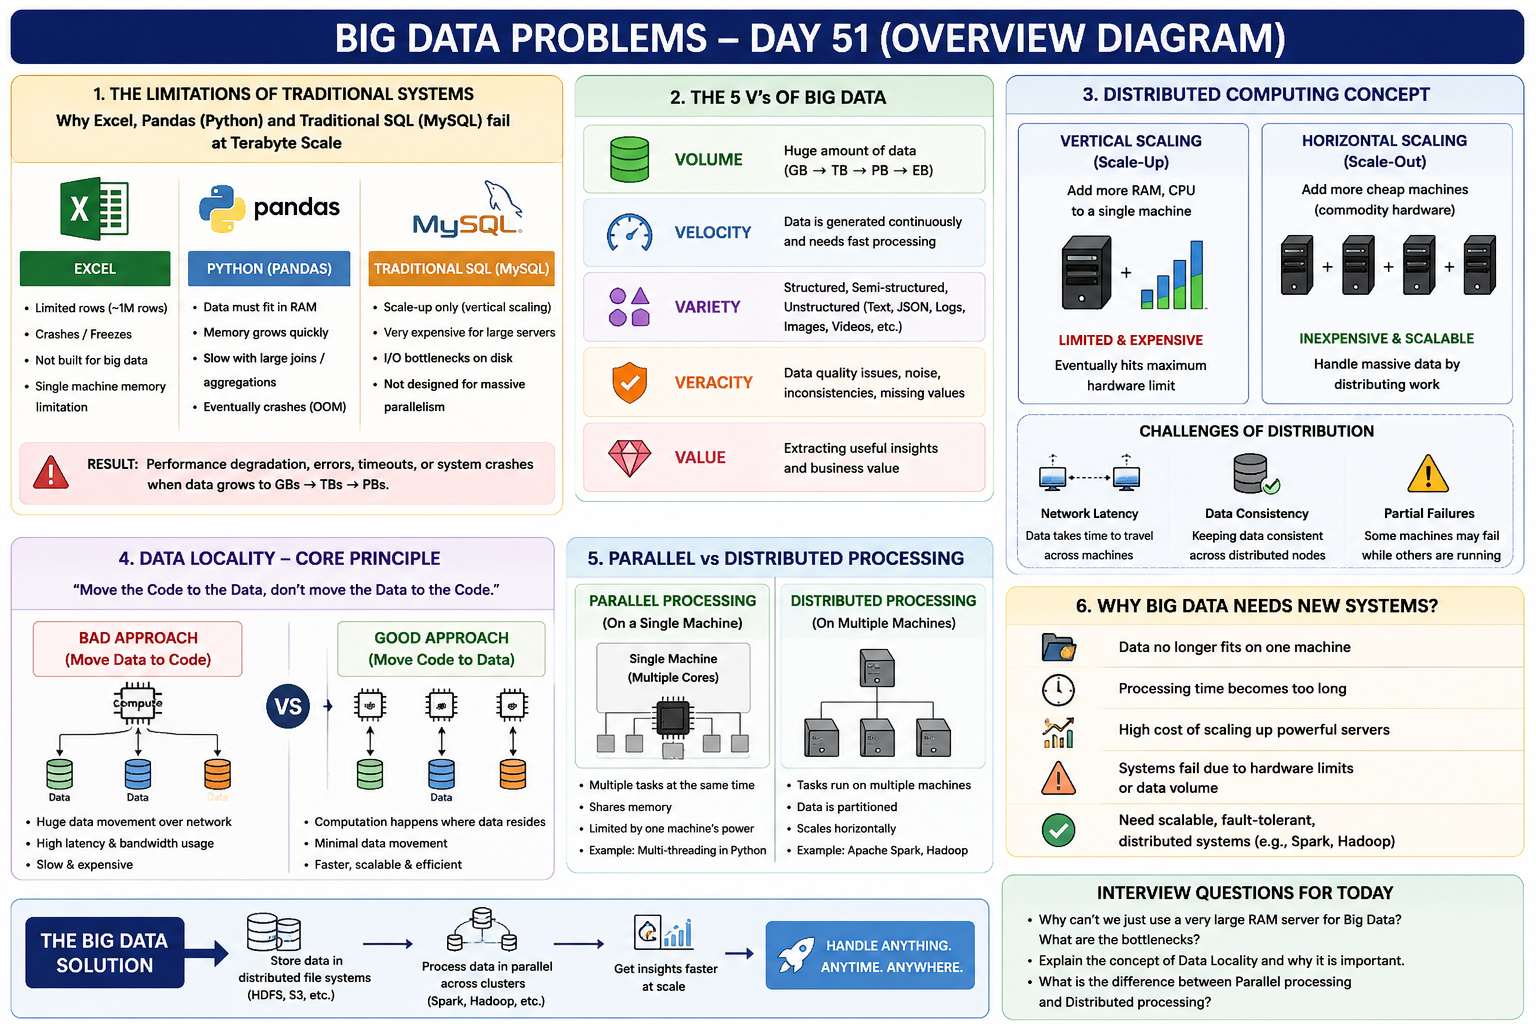

# 19. Practice Problems

## Practice 1: 5 V's

For each scenario, identify the 5 V's.

### Scenario A

A bank processes card transactions from millions of customers in real time and detects fraud.

### Scenario B

A video streaming platform stores watch history, clicks, search logs, and playback quality events.

### Scenario C

A hospital stores patient records, lab reports, scans, and sensor readings from ICU machines.


In [ ]:
# Write your answers here

answers = {
    "banking_fraud": {
        "volume": "",
        "velocity": "",
        "variety": "",
        "veracity": "",
        "value": ""
    },
    "video_streaming": {
        "volume": "",
        "velocity": "",
        "variety": "",
        "veracity": "",
        "value": ""
    },
    "hospital_data": {
        "volume": "",
        "velocity": "",
        "variety": "",
        "veracity": "",
        "value": ""
    }
}

answers


{'banking_fraud': {'volume': '',
  'velocity': '',
  'variety': '',
  'veracity': '',
  'value': ''},
 'video_streaming': {'volume': '',
  'velocity': '',
  'variety': '',
  'veracity': '',
  'value': ''},
 'hospital_data': {'volume': '',
  'velocity': '',
  'variety': '',
  'veracity': '',
  'value': ''}}

## Practice 2: Scaling Decision

A company has a Pandas job that processes 20 GB data daily. It now needs to process 5 TB daily.

Answer:

1. Would you use vertical scaling or horizontal scaling?
2. Why?
3. What new problems may appear after moving to distributed processing?


In [ ]:
# Write your answer here


## Practice 3: Data Locality

You have three machines:

```text
Machine A: 500 GB logs
Machine B: 600 GB logs
Machine C: 400 GB logs
```

You need only the total count of error events.

Which is better?

```text
Option 1: Move all logs to one machine and count.
Option 2: Count errors on each machine and combine counts.
```

Explain why.


In [ ]:
# Write your answer here


# 20. Interview Questions and Answers

## Q1. Why can't we just use a very large RAM server for Big Data? What are the bottlenecks?

A very large RAM server may help for some workloads, but it does not solve the full Big Data problem.

Bottlenecks include:

```text
hardware cost
maximum machine size
single point of failure
disk I/O
network I/O
CPU limits
backup and recovery time
concurrent users
scaling beyond one machine
```

Distributed systems scale horizontally by adding more machines.


## Q2. Explain the concept of Data Locality and why it is important.

Data locality means processing data close to where it is stored.

The principle is:

```text
Move the code to the data, not the data to the code.
```

It is important because moving large datasets across a network is slow and expensive.

Big Data systems reduce network movement by sending computation to the machines that already hold the data.


## Q3. What is the difference between Parallel Processing and Distributed Processing?

Parallel processing means doing multiple tasks at the same time.

It can happen on one machine using multiple CPU cores.

Distributed processing means spreading work across multiple machines connected by a network.

A distributed system often uses parallel processing, but it also has to handle network latency, failures, and coordination.


# 21. Final Summary

Today's key message:

```text
Big Data is not just about large files.
It is about scale, speed, complexity, quality, and business value.
```

Traditional tools are useful, but they can struggle when:

```text
data does not fit in memory
processing takes too long
many users query at once
data arrives continuously
failures need to be handled automatically
```

Distributed systems solve this by:

```text
splitting data
processing partitions in parallel
adding more machines horizontally
reducing data movement through data locality
handling failures across machines
```

This foundation prepares us for Apache Spark architecture.
